### Train--Model Definition

#### 一、Model Definition

#### 1. 模型设计的核心底层依据
- 任务本质：明确要解决什么问题


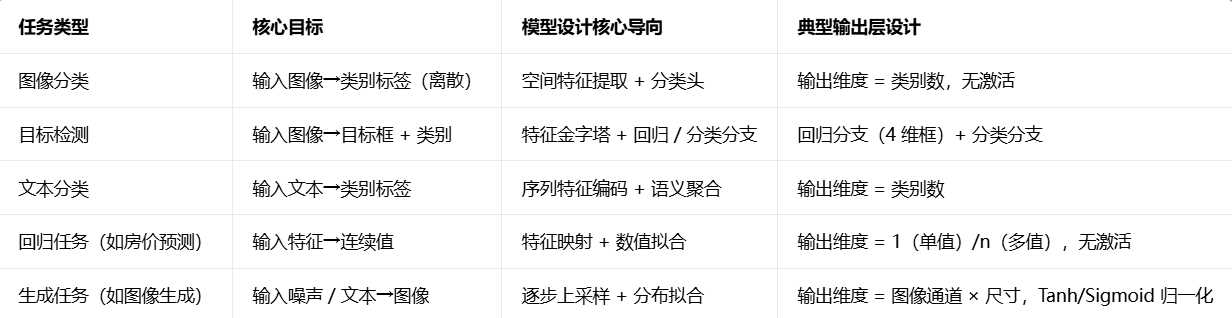

#### 2.数据特征：匹配“数据的先天属性“
  - 数据维度
    - 一维序列(文本/时间序列)：优先RNN／Transformer（处理序列依赖），层参数需要考虑序列长度、词嵌入维度
    - 二维图像：优先用CNN（处理空间局部相关性），层参数需要考虑图像尺寸、通道数
    - 高维表格数据：优先MLP（无空间/序列依赖），层参数需要考虑特征维度

- 数据规模
  - 小数据集（万级以内）：用浅模型+少参数(避免过拟合)
  - 大数据集（百万级以上）：用深模型+多参数
- 数据噪声：噪声大的数据集（医疗影像、低质量文本），需要进行正则化

#### 3.核心参数的设置
- 模型参数分为：层内可训练参数（全连接层维度，卷积核大小等）  
- 超参数：学习率，批次大小等

1） 网络深度（层数）：浅拟合，深表达
- 设置依据
  - 任务复杂度：简单任务（2，3层）；复杂任务（数十层）
  - 梯度消失/爆炸：深度超过10层需要残差连接，层归一化，否则训练不收敛
  - 过拟合风险：小数据集+深网络=过拟合，需要正则化处理
- 通用经验：
  - 从浅模型开始迭代：先基线模型，再逐步加深，直到验证集效果不再提升
  - 深度与宽度互补：深而窄的模型（ResNet50,通道数256）比浅而宽的模型更加高效

2）网络宽度（层维度/通道数）：”特征表达能力“的核心
宽度指每层的输出维度，是影响参数量的核心
- 设置依据
  - 输入特征维度：MLP第一层维度通常$>=$输入特征维度,保证特征映射的充分性
  - 任务复杂度：复杂任务需要更宽的层
  - 算力约束：宽度翻倍->参数量平方级增加/线性增加，需控制在算力可承受范围

3） 通用经验：
- 采用递减/递增策略
  - MLP：输入层－隐藏层－输出层，维度逐步递减，符合特征抽象－－压缩
  - CNN：下采样阶段通道数递增，上采样阶段递减

以多层感知机为例，做手写数字识别任务

In [17]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']     # 显示中文
matplotlib.rcParams['axes.unicode_minus'] = False

In [18]:
# 数据加载
transform = transforms.ToTensor()
train_data = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

In [19]:
#定义模型
net = nn.Sequential(
    nn.Flatten(),           # 将 28x28 展平为 784
    nn.Linear(784, 256),    # 隐藏层1
    nn.ReLU(),              # 激活函数
    nn.Linear(256, 10)      # 输出层（10类）
)

- Linear层:实现线性变换
- ReLU层:实现ReLU激活函数
- Flatten层:将输入的矩阵变换为一维向量

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备：{device}")
# 初始化参数
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, std=0.01)
net.apply(init_weights)

net = net.to(device)

使用设备：cuda


#### 二、Activation functions

1. 为什么需要激活函数？
- 如果没有激活函数，不管神经网络有多少层，最终的计算结果都是输入*权重+偏置的线性组合，无法学会复杂的特征
- 激活函数可以将输入映射成为非线性输出空间，学习复杂特征



2. 常见激活函数

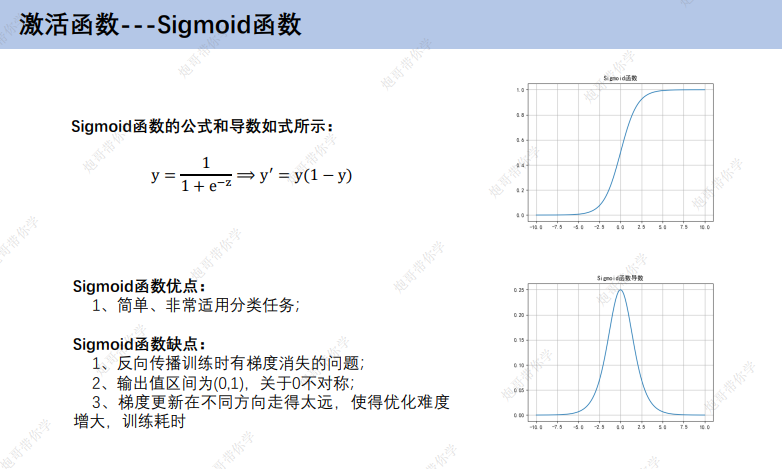

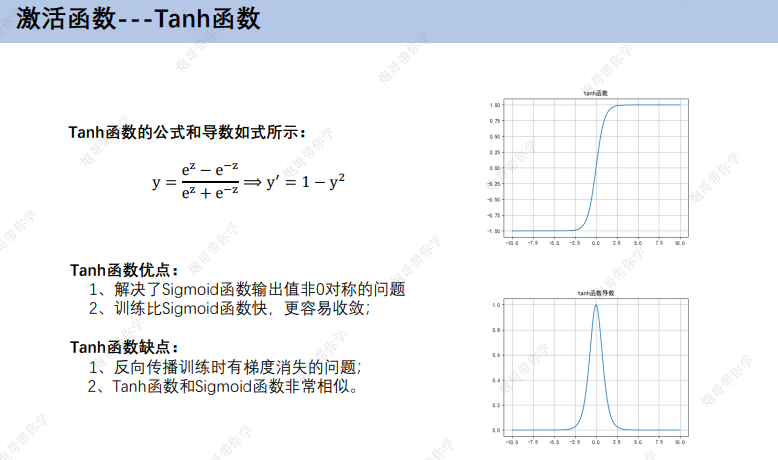

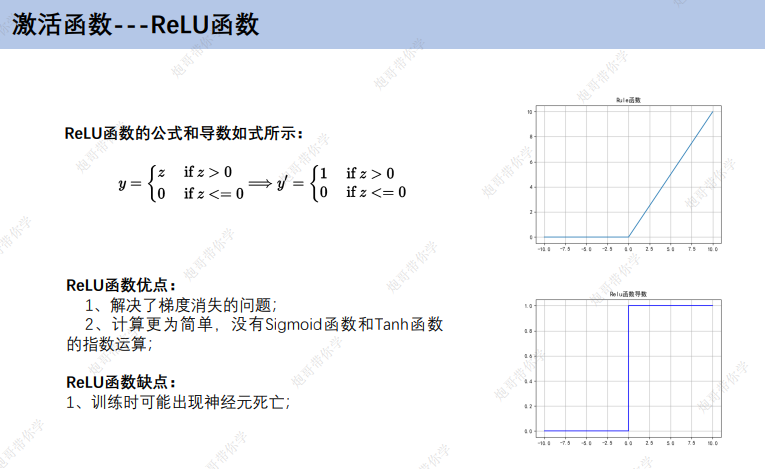

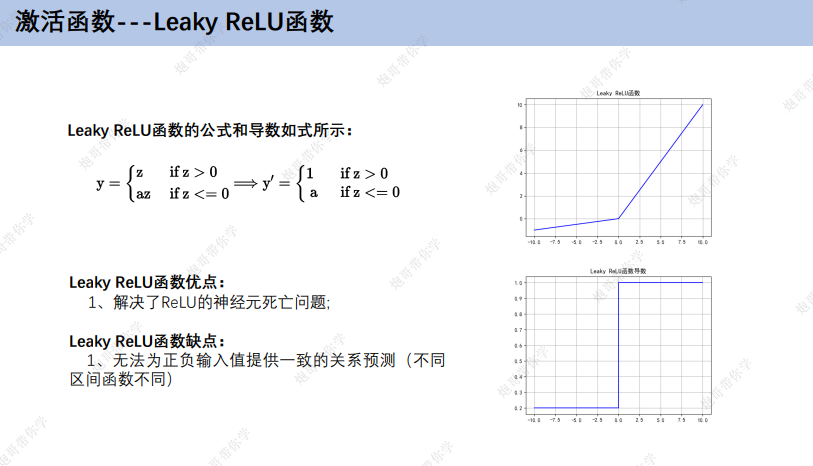

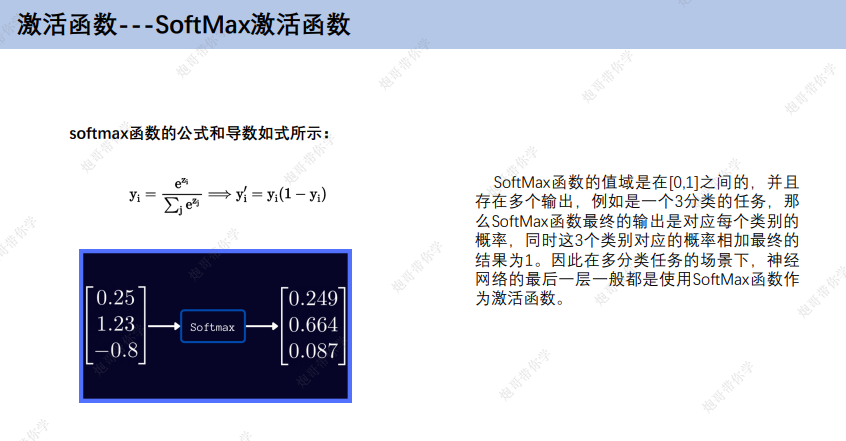

In [21]:
# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.1)

#### 三、Loss Function 

1. 基础认知
- 损失函数是一个非负实值函数，模型训练的目标就是最小化损失函数的均值
- 计算真实标签与模型预测输出间的差距，将抽象的“预测不准”转换为可以计算的数值
- 通过梯度下降，沿损失减小的方向更新参数

2. 两大分类
- 回归任务（预测连续值）：
  - 均方误差损失（MSE）
    - 数学表达：$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y_i})^2$
    - 对误差取平方，放大大误差，惩罚严重错误，梯度随误差增大而增大
    - 适用场景：数据无异常值、噪声服从高斯分布的回归任务
  - 平方绝对误差损失（MAE）：
    - 数学表达：$MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y_i}|$
    - 误差的绝对值，对所有误差一视同仁
    - 适用场景：数据包含大量异常值的回归任务


- 分类任务（预测离散值）：
  - 二元交叉熵（BCE）
    - 数学表达：$BCE = -\frac{1}{n}\sum_{i=1}^{n}y_i \log(\hat{y_i})$
    - 模型最后一层用sigmoid激活
    - 适用场景：二分类任务
  - 多分类交叉熵损失(CE)
    - 数学表达：$CE = -\frac{1}{n}\sum_{i=1}^{n}\sum_{j=1}^{k}y_{ij} \log(\hat{y_{ij}})$
    - 模型最后一层用softmax激活
    - 适用场景：多分类任务


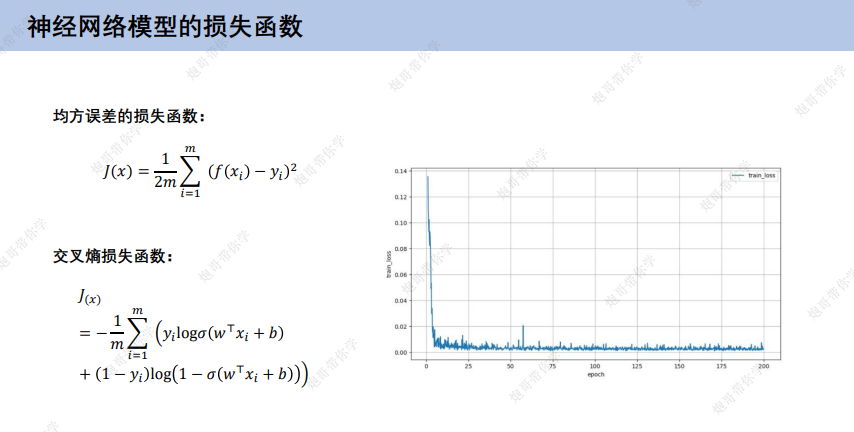

In [22]:
num_epochs = 10
def train_model(net, train_loader, test_loader, num_epochs, criterion, optimizer, device):
    # 初始化记录训练过程的列表
    train_loss_list = []
    train_acc_list = []
    test_acc_list = []
    
    for epoch in range(num_epochs):
        net.train()
        total_loss, correct, total = 0.0, 0, 0

        for X, y in train_loader:
            X, y = X.to(device), y.to(device)

            # 前向传播
            y_hat = net(X)
            loss = criterion(y_hat, y)

            # 反向传播
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * y.size(0)
            correct += (y_hat.argmax(1) == y).sum().item()
            total += y.size(0)

        train_loss = total_loss / total
        train_acc = correct / total
        
        # 记录训练数据
        train_loss_list.append(train_loss)
        train_acc_list.append(train_acc)

        # 测试阶段
        net.eval()
        with torch.no_grad():
            correct, total = 0, 0
            for X, y in test_loader:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                correct += (y_hat.argmax(1) == y).sum().item()
                total += y.size(0)
        test_acc = correct / total
        test_acc_list.append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] | "
              f"Train Loss: {train_loss:.4f} | "
              f"Train Acc: {train_acc*100:.2f}% | "
              f"Test Acc: {test_acc*100:.2f}%")
    
    # 训练完成后绘制可视化图表
    plot_training_curve(num_epochs, train_loss_list, train_acc_list, test_acc_list)

In [23]:
def plot_training_curve(num_epochs, train_loss, train_acc, test_acc):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    epochs = np.arange(1, num_epochs + 1)
    
    # 训练损失曲线
    ax1.plot(epochs, train_loss, 'b-', linewidth=2, label='训练损失')
    ax1.set_xlabel('Epoch（轮次）')
    ax1.set_ylabel('Loss（损失）')
    ax1.set_title('FashionMNIST MLP 训练损失变化')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 训练/测试准确率对比
    ax2.plot(epochs, [x*100 for x in train_acc], 'r-', linewidth=2, label='训练准确率')
    ax2.plot(epochs, [x*100 for x in test_acc], 'g-', linewidth=2, label='测试准确率')
    ax2.set_xlabel('Epoch（轮次）')
    ax2.set_ylabel('Accuracy（准确率 %）')
    ax2.set_title('FashionMNIST MLP 训练/测试准确率对比')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 调整子图间距
    plt.tight_layout()
    plt.show()

Epoch [1/10] | Train Loss: 1.0427 | Train Acc: 64.08% | Test Acc: 76.20%
Epoch [2/10] | Train Loss: 0.5973 | Train Acc: 79.06% | Test Acc: 80.49%
Epoch [3/10] | Train Loss: 0.5187 | Train Acc: 81.77% | Test Acc: 82.25%
Epoch [4/10] | Train Loss: 0.4813 | Train Acc: 83.17% | Test Acc: 81.25%
Epoch [5/10] | Train Loss: 0.4542 | Train Acc: 84.04% | Test Acc: 83.05%
Epoch [6/10] | Train Loss: 0.4340 | Train Acc: 84.73% | Test Acc: 83.42%
Epoch [7/10] | Train Loss: 0.4167 | Train Acc: 85.18% | Test Acc: 83.94%
Epoch [8/10] | Train Loss: 0.4033 | Train Acc: 85.79% | Test Acc: 83.22%
Epoch [9/10] | Train Loss: 0.3951 | Train Acc: 86.12% | Test Acc: 83.61%
Epoch [10/10] | Train Loss: 0.3841 | Train Acc: 86.46% | Test Acc: 82.98%


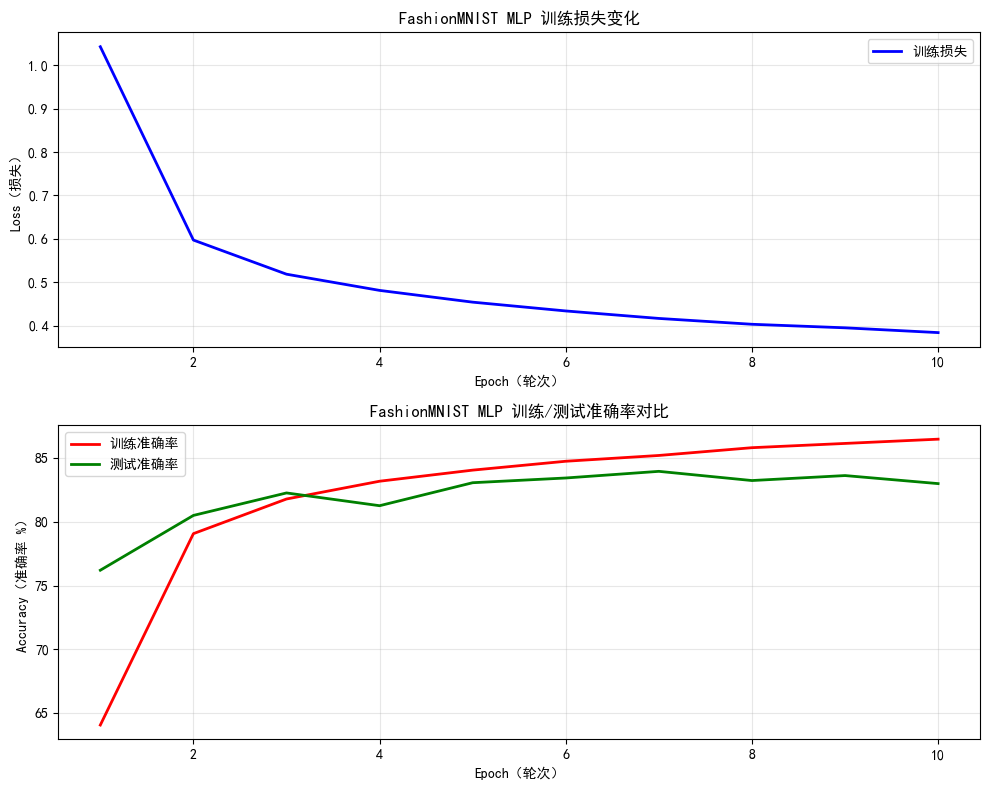

In [16]:
train_model(net, train_loader, test_loader, num_epochs, criterion, optimizer, device)


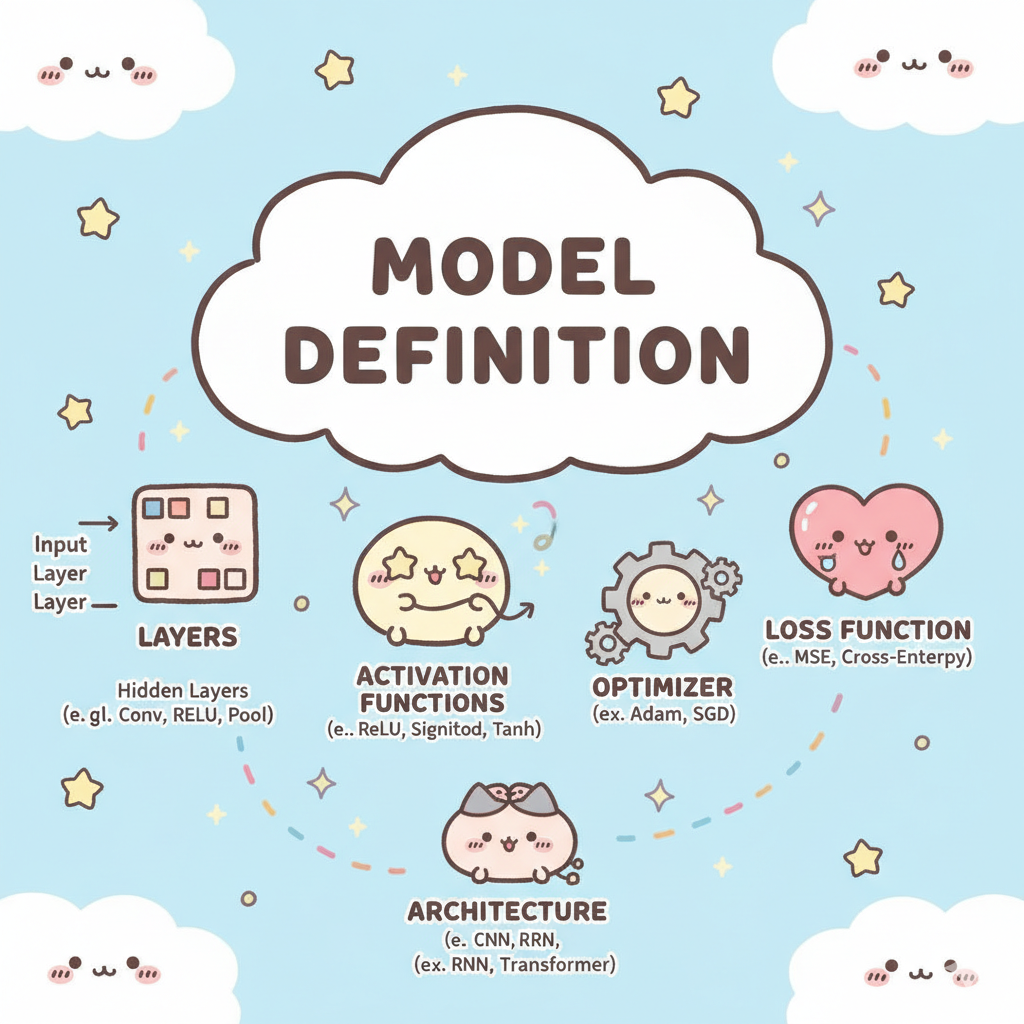